In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import classification_report, confusion_matrix

import warnings
warnings.filterwarnings('ignore')

In [2]:
print(f"TensorFlow Version: {tf.__version__}")
print(f"Keras Version: {keras.__version__}")

gpus = tf.config.list_physical_devices('GPU')

print(f"GPUs Available: {len(gpus)}")

TensorFlow Version: 2.21.0
Keras Version: 3.14.1
GPUs Available: 0


In [5]:
(X_train, y_train), (X_test, y_test) = keras.datasets.cifar10.load_data()

print("=== CIFAR-10 Dataset Information ===")

print(f"Training Images : {X_train.shape}")
print(f"Training Labels : {y_train.shape}")

print(f"Test Images : {X_test.shape}")
print(f"Test Labels : {y_test.shape}")

print(f"Pixel Range : {X_train.min()} to {X_train.max()}")

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 21s 0us/step
=== CIFAR-10 Dataset Information ===
Training Images : (50000, 32, 32, 3)
Training Labels : (50000, 1)
Test Images : (10000, 32, 32, 3)
Test Labels : (10000, 1)
Pixel Range : 0 to 255


In [7]:
class_names = [

'airplane',

'automobile',

'bird',

'cat',

'deer',

'dog',

'frog',

'horse',

'ship',

'truck'

]

print(class_names)

['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


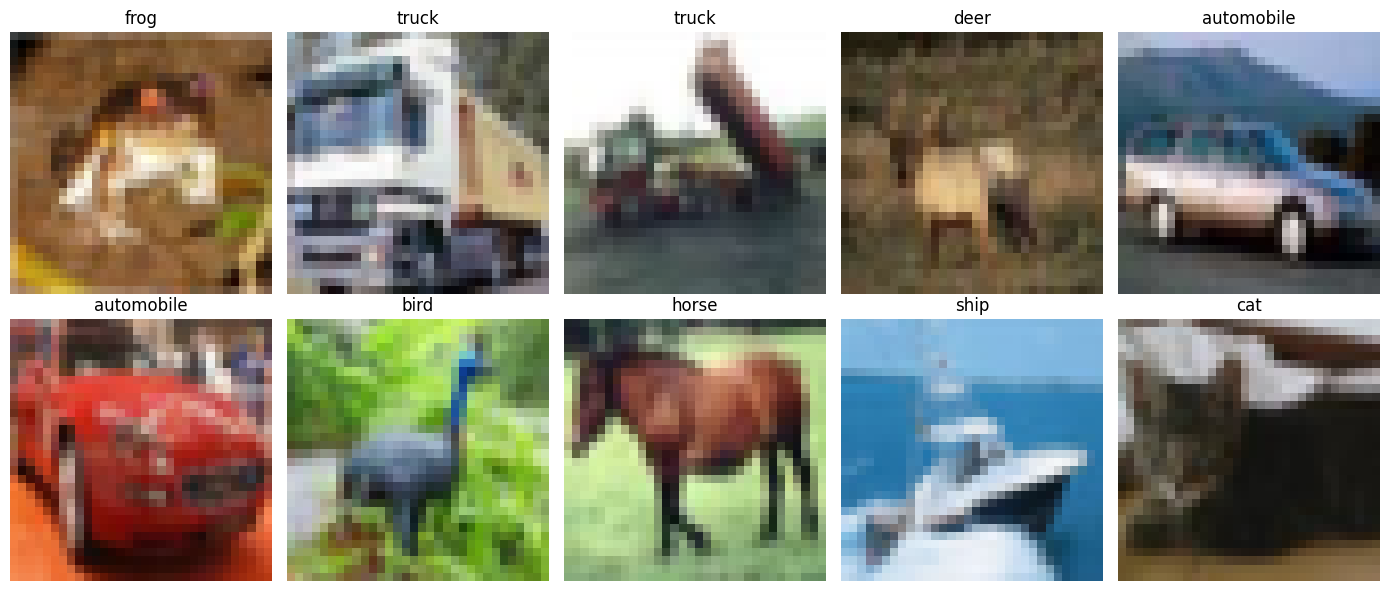

In [9]:
fig, axes = plt.subplots(2,5, figsize=(14,6))

for i in range(10):

    ax = axes[i//5, i%5]

    ax.imshow(X_train[i])

    ax.set_title(class_names[int(y_train[i])])

    ax.axis('off')

plt.tight_layout()

plt.savefig(
    'cifar10_classes.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

In [11]:
# Normalize pixel values

X_train_norm = X_train.astype('float32') / 255.0

X_test_norm = X_test.astype('float32') / 255.0

print(X_train_norm.min(), X_train_norm.max())

0.0 1.0


In [13]:
from tensorflow.keras.utils import to_categorical

y_train_ohe = to_categorical(y_train, 10)

y_test_ohe = to_categorical(y_test, 10)

print(y_train[0])

print(y_train_ohe[0])

[6]
[0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]


In [15]:
datagen = ImageDataGenerator(

    rotation_range=15,

    width_shift_range=0.1,

    height_shift_range=0.1,

    horizontal_flip=True,

    zoom_range=0.1

)

datagen.fit(X_train_norm)

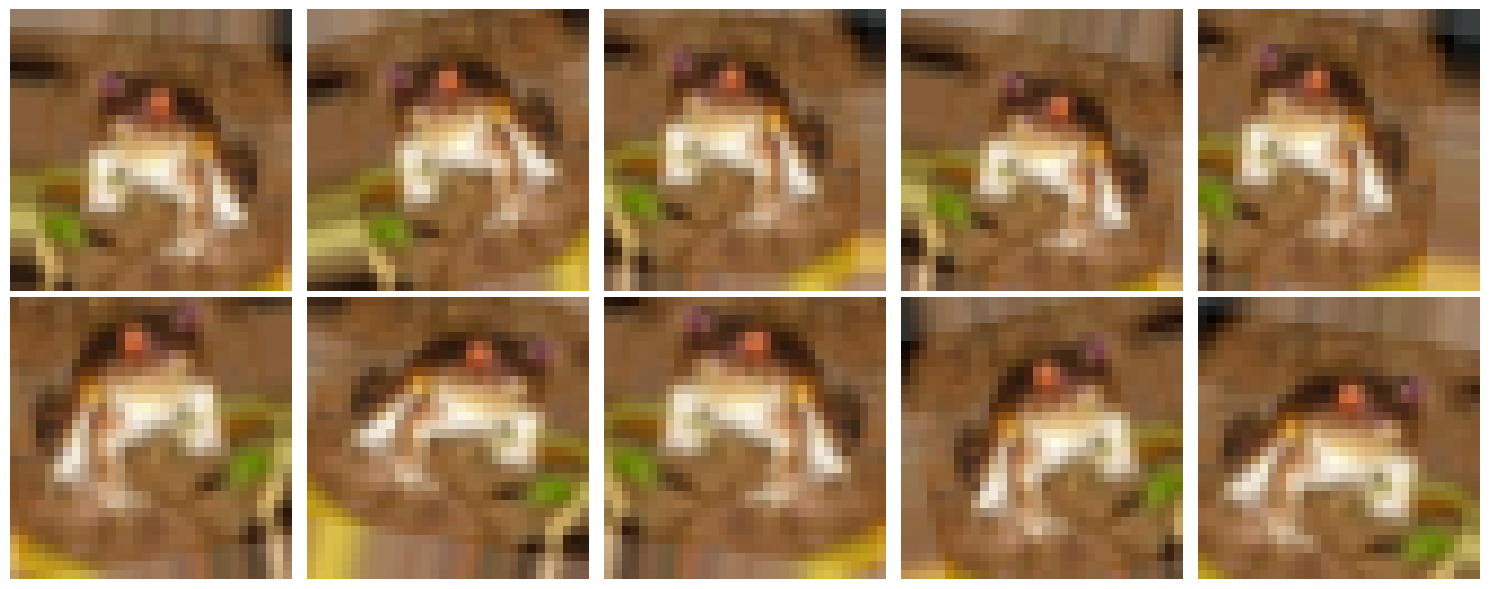

In [17]:
fig, axes = plt.subplots(2,5, figsize=(15,6))

sample = X_train_norm[0].reshape((1,32,32,3))

i = 0

for batch in datagen.flow(sample, batch_size=1):

    axes[i//5, i%5].imshow(batch[0])

    axes[i//5, i%5].axis('off')

    i += 1

    if i == 10:
        break

plt.tight_layout()

plt.savefig(
    'data_augmentation.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

In [23]:
def build_cifar10_cnn(input_shape=(32,32,3), num_classes=10):

    model = models.Sequential([

        # Block 1
        layers.Conv2D(
            32,
            (3,3),
            activation='relu',
            padding='same',
            input_shape=input_shape
        ),

        layers.BatchNormalization(),

        layers.Conv2D(
            32,
            (3,3),
            activation='relu',
            padding='same'
        ),

        layers.MaxPooling2D((2,2)),

        layers.Dropout(0.25),

        # Block 2
        layers.Conv2D(
            64,
            (3,3),
            activation='relu',
            padding='same'
        ),

        layers.BatchNormalization(),

        layers.Conv2D(
            64,
            (3,3),
            activation='relu',
            padding='same'
        ),

        layers.MaxPooling2D((2,2)),

        layers.Dropout(0.25),

        # Block 3
        layers.Conv2D(
            128,
            (3,3),
            activation='relu',
            padding='same'
        ),

        layers.BatchNormalization(),

        layers.MaxPooling2D((2,2)),

        layers.Dropout(0.25),

        # Classifier
        layers.Flatten(),

        layers.Dense(
            256,
            activation='relu'
        ),

        layers.Dropout(0.5),

        layers.Dense(
            num_classes,
            activation='softmax'
        )

    ])

    return model

In [25]:
model = build_cifar10_cnn()

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 32, 32, 32)          │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 32, 32, 32)          │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 32, 32, 32)          │           9,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 16, 16, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 16, 16, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 16, 16, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 16, 16, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 16, 16, 64)          │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 8, 8, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 8, 8, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (None, 8, 8, 128)           │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 8, 8, 128)           │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 4, 4, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 4, 4, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 2048)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 256)                 │         524,544 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 10)                  │           2,570 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 667,434 (2.55 MB)

 Trainable params: 666,986 (2.54 MB)

 Non-trainable params: 448 (1.75 KB)

In [27]:
model.compile(

    optimizer='adam',

    loss='categorical_crossentropy',

    metrics=['accuracy']

)

In [29]:
callbacks = [

    EarlyStopping(

        monitor='val_accuracy',

        patience=5,

        restore_best_weights=True

    ),

    ReduceLROnPlateau(

        monitor='val_loss',

        factor=0.5,

        patience=3,

        min_lr=1e-7

    )

]

In [31]:
history = model.fit(

    datagen.flow(
        X_train_norm,
        y_train_ohe,
        batch_size=64
    ),

    epochs=20,

    validation_data=(
        X_test_norm,
        y_test_ohe
    ),

    callbacks=callbacks,

    verbose=1

)

Epoch 1/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 93s 112ms/step - accuracy: 0.3270 - loss: 1.8470 - val_accuracy: 0.4067 - val_loss: 1.7402 - learning_rate: 0.0010
Epoch 2/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 92s 118ms/step - accuracy: 0.4514 - loss: 1.5163 - val_accuracy: 0.5060 - val_loss: 1.4046 - learning_rate: 0.0010
Epoch 3/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 90s 115ms/step - accuracy: 0.5251 - loss: 1.3300 - val_accuracy: 0.5479 - val_loss: 1.3360 - learning_rate: 0.0010
Epoch 4/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 90s 115ms/step - accuracy: 0.5736 - loss: 1.2132 - val_accuracy: 0.6507 - val_loss: 1.0520 - learning_rate: 0.0010
Epoch 5/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 89s 113ms/step - accuracy: 0.6101 - loss: 1.1190 - val_accuracy: 0.6514 - val_loss: 1.0157 - learning_rate: 0.0010
Epoch 6/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 87s 111ms/step - accuracy: 0.6341 - loss: 1.0532 - val_accuracy: 0.7056 - val_loss: 0.8615 - learning_rate: 0.0010
Epoch 7/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 83s 106ms/step - accuracy: 0.6